In [22]:
# only for development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [30]:
from src.experiments.ica import ICA


In [31]:
X, A = ICA.generate_artificial_data(N=1000, D=6)
ICA_exp = ICA()

W_sgld, samples_sgld, iters_sgld = ICA_exp.run_sgld(X, steps=50000, batch_size=100)

In [32]:
samples_sgld.shape

(17964, 6, 6)

In [33]:
# corrected langevin MCMC
W_corr, samples_corr, iters_corr = ICA_exp.run_corrected_langevin(X, W_init=W_sgld, steps=50000)

Step 0/50000 | Acceptance Rate: 0.0000
Step 10000/50000 | Acceptance Rate: 0.7760
Step 20000/50000 | Acceptance Rate: 0.7750
Step 30000/50000 | Acceptance Rate: 0.7755
Step 40000/50000 | Acceptance Rate: 0.7755
Final Acceptance Rate: 0.7745


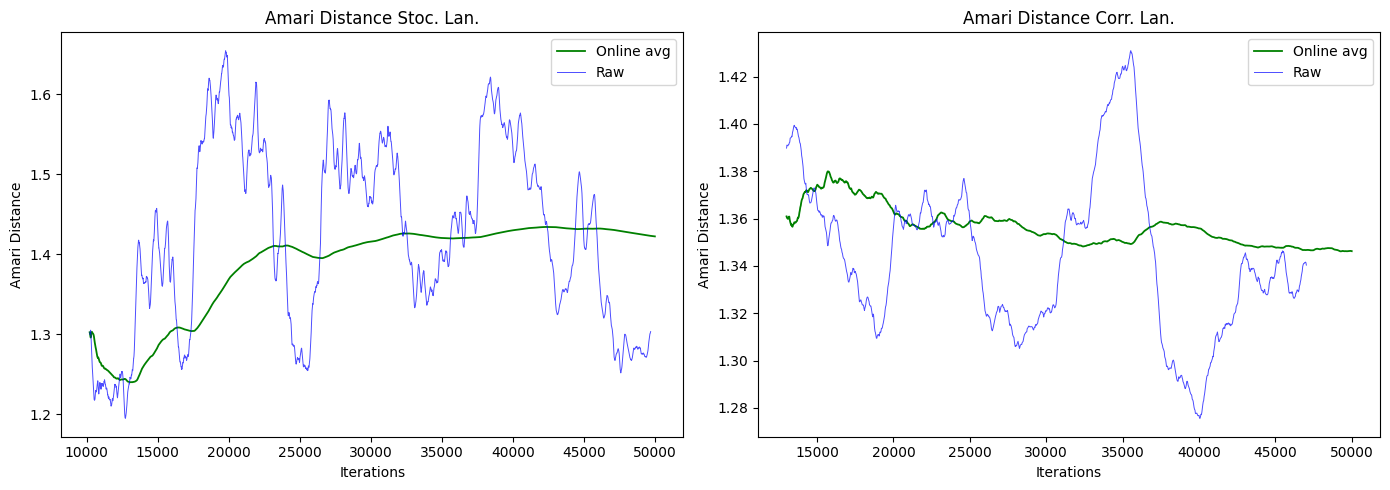

In [34]:
# amari distances
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ICA_exp.plot_amari_distances(samples_sgld, A, iters_sgld, experiment="Stoc. Lan.", ax=axes[0])
ICA_exp.plot_amari_distances(samples_corr, A, iters_corr, experiment="Corr. Lan.", ax=axes[1])
plt.tight_layout()
plt.show()

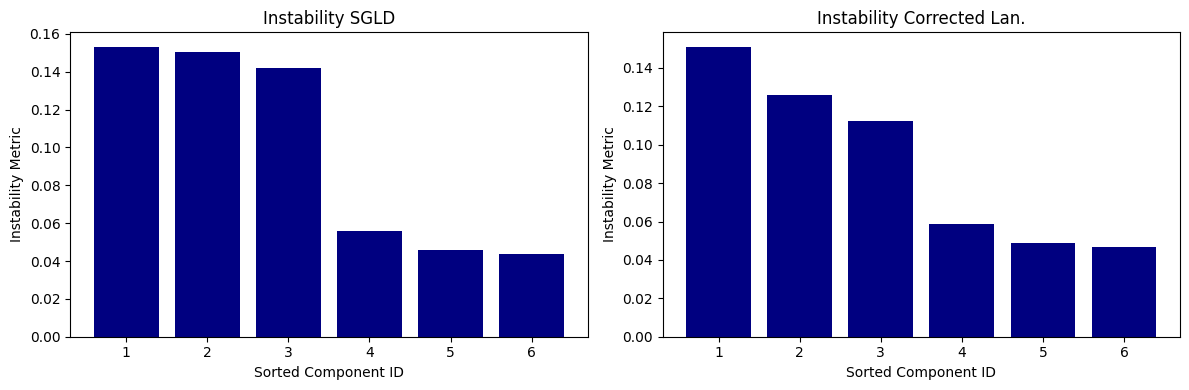

In [35]:
# instability
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ICA.plot_instability(samples_sgld, X, "Instability SGLD", ax=axes[0])
ICA.plot_instability(samples_corr, X, "Instability Corrected Lan.", ax=axes[1])
plt.tight_layout()
plt.show()

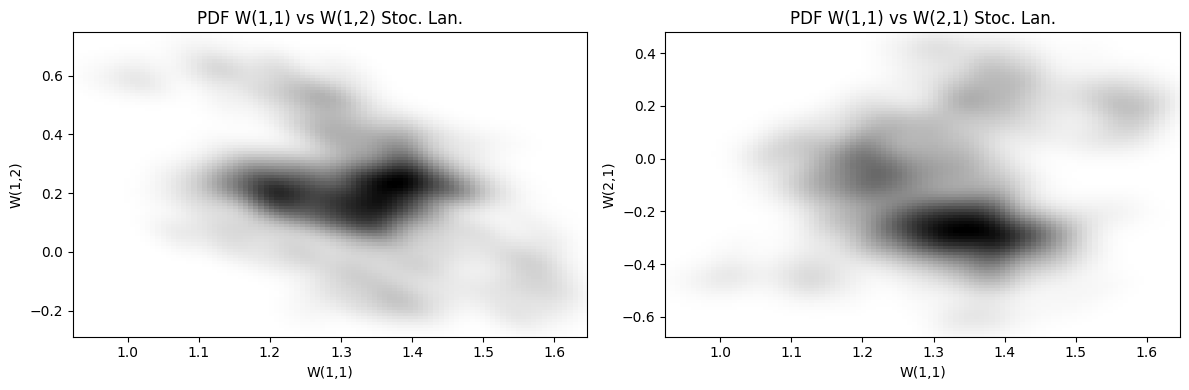

In [ ]:
# 2d pdfs
ICA.plot_2d_pdfs(samples_sgld, "Stoc. Lan.")

ICA.plot_2d_pdfs(samples_corr, "Corr. Lan.")
